In [43]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from cropEyeRegion import getCroppedEyeRegion

%matplotlib inline

In [44]:
import matplotlib
matplotlib.rcParams['figure.figsize'] = (10.0,10.0)
matplotlib.rcParams['image.cmap'] = 'gray'

In [45]:
predictions2Label = {0: "No Glasses", 1: "With Glasses"}

In [46]:
# Path 1 is class 0 and path 2 is class 1
path1 = 'data/images/glassesDataset/cropped_withoutGlasses2'
path2 = 'data/images/glassesDataset/cropped_withGlasses2'

In [47]:
def getTrainTest(path, class_val, test_fraction=0.2):
    trainData = []
    testData = []
    trainLabels = []
    testLabels = []
    inputDir = os.path.expanduser(path)

    if os.path.isdir(inputDir):
        images = os.listdir(inputDir)
        images.sort()
        nTest = int(len(images) * test_fraction)

    for counter, img in enumerate(images):
        im = cv2.imread(os.path.join(inputDir, img))

        if counter < nTest:
            testData.append(im)
            testLabels.append(class_val)
        else:
            trainData.append(im)
            trainLabels.append(class_val)

    return trainData, trainLabels, testData, testLabels

In [48]:
def svmInit(C, gamma):
    model = cv2.ml.SVM_create()
    model.setGamma(gamma)
    model.setC(C)
    model.setKernel(cv2.ml.SVM_RBF)
    model.setType(cv2.ml.SVM_C_SVC)

    return model

In [49]:
def svmTrain(model, samples, responses):
    model.train(samples, cv2.ml.ROW_SAMPLE, responses)
    return model

In [50]:
def svmPredict(model, samples):
    return model.predict(samples)[1].ravel()

In [51]:
def svmEvaluate(model, samples, labels):
    predictions = svmPredict(model, samples)
    accuracy = (labels == predictions).mean()
    print('Percentage Accuracy: %.2f %%' % (accuracy*100))
    return accuracy

In [52]:
def prepareData(data):
    featureVectorLength = len(data[0])
    features = np.float32(data).reshape(-1, featureVectorLength)
    return features

In [53]:
def computeHOG(hog, data):
    hogData = []
    for image in data:
        hogFeatures = hog.compute(image)
        hogData.append(hogFeatures)

    return hogData

In [54]:
# Initialize hog params
winSize = (96, 32)
blockSize = (8, 8)
blockStride = (8, 8)
cellSize = (4, 4)
nbins = 9
derivAperture = 0
winSigma = 4.0
histogramNormType = 1
L2HysThreshold = 2.0000000000000001e-01
gammaCorrection = 1
nlevels = 64

hog = cv2.HOGDescriptor(winSize, blockSize, blockStride, cellSize, 
                      nbins,derivAperture, winSigma, 
                      histogramNormType,L2HysThreshold, 
                      gammaCorrection, nlevels, 1)

In [55]:
# Get training and testing images for both classes
negTrainImages, negTrainLabels, negTestImages, negTestLabels = \
getTrainTest(path1, 0, .2)
posTrainImages, posTrainLabels, posTestImages, posTestLabels = \
getTrainTest(path2, 1, .2)

# Append Positive and Negative Images for Train and Test
trainImages = np.concatenate((np.array(negTrainImages), 
                        np.array(posTrainImages)), 
                            axis=0)
testImages = np.concatenate((np.array(negTestImages), 
                          np.array(posTestImages)), 
                          axis=0)

# Append Positive and Negative Labels for Train and Test
trainLabels = np.concatenate((np.array(negTrainLabels), 
                          np.array(posTrainLabels)), 
                          axis=0)
testLabels = np.concatenate((np.array(negTestLabels), 
                          np.array(posTestLabels)), 
                          axis=0)

In [56]:
### Feature computation for the training and testing data  ##
trainHOG = computeHOG(hog, trainImages)
testHOG = computeHOG(hog, testImages)

# Convert hog data into features recognized by SVM model
trainFeatures = prepareData(trainHOG)
testFeatures = prepareData(testHOG)

In [57]:
###########  SVM Training  ##############
model = svmInit(C=2.5, gamma=0.02)  # C = 0.1, gamma 10 for 
#linear kernel
model = svmTrain(model, trainFeatures, trainLabels)
model.save("eyeGlassClassifierModel.yml")

In [58]:
##########  SVM Testing  ###############
# We will load the model again and test the model
# This is just to explain how to load an SVM model
# You can use the model directly
savedModel = cv2.ml.SVM_load("eyeGlassClassifierModel.yml")

# Find accuracy of the test data by evaluating the model on 
# the test data
accuracy = svmEvaluate(savedModel, testFeatures, testLabels)

Percentage Accuracy: 92.45 %


In [ ]:
# Perform for a separate test image
filename = "data/images/glassesDataset/glasses_4.jpg"
testImage = cv2.imread(filename)
cropped = getCroppedEyeRegion(testImage)
testHOG = computeHOG(hog, np.array([cropped]))
testFeatures = prepareData(testHOG)
predictions = svmPredict(savedModel, testFeatures)
print("Prediction = {}"
      .format(predictions2Label[int(predictions[0])]))

Eye Height between : 49,148
Prediction = With Glasses


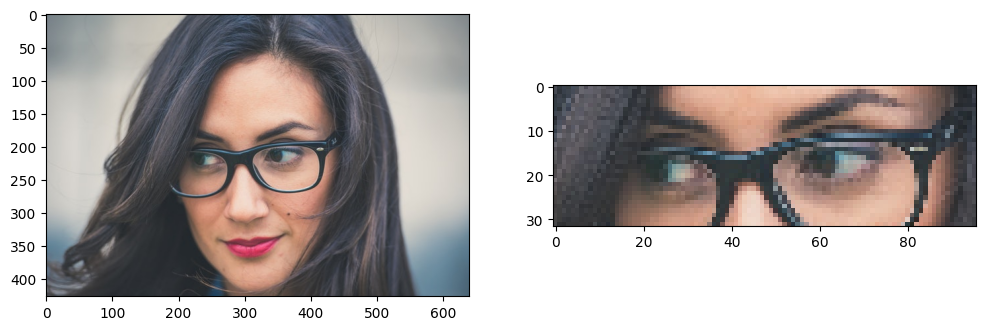

In [61]:
plt.figure(figsize=(12,12))
plt.subplot(1,2,1)
plt.imshow(testImage[:,:,::-1])
plt.subplot(1,2,2)
plt.imshow(cropped[:,:,::-1])
plt.show()

In [62]:
# Perform for a separate test image
filename = "data/images/glassesDataset/no_glasses1.jpg"
testImage = cv2.imread(filename)
cropped = getCroppedEyeRegion(testImage)
testHOG = computeHOG(hog, np.array([cropped]))
testFeatures = prepareData(testHOG)
predictions = svmPredict(savedModel, testFeatures)
print("Prediction = {}"
      .format(predictions2Label[int(predictions[0])]))

Eye Height between : 26,79
Prediction = No Glasses


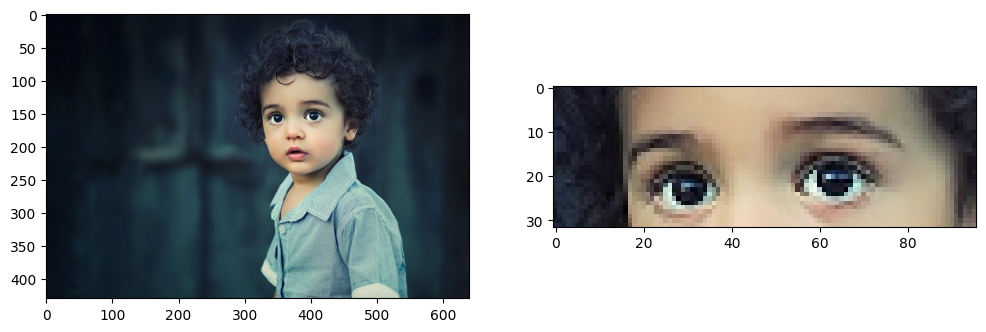

In [63]:
plt.figure(figsize=(12,12))
plt.subplot(1,2,1)
plt.imshow(testImage[:,:,::-1])
plt.subplot(1,2,2)
plt.imshow(cropped[:,:,::-1])
plt.show()